## Training a TiDE model for the linear dynamic system, $x_{k+1}=Ax_k+Bu_k$
Contributers: Ying-Kuan (Creating the script based on Yi-Ping's TiDE model: generating data, training the model, and plotting) & Yi-Ping (creating the code for TiDE modeling)

updated with longer time series


In [32]:
# Import all the packages we need
import numpy as np
import pandas as pd
from typing import Optional, Tuple

import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.graph_objects as go

from pickle import dump
from sklearn.preprocessing import MinMaxScaler
import time

# from pytorch_forecasting.metrics.quantile import QuantileLoss

# For LSTM
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from tqdm import tqdm

if torch.cuda.is_available():
    print("cuda is available")
else:
    print("cuda is NOT available")

from sklearn.preprocessing import StandardScaler
from torch.nn import functional as F

# For TFT
from tqdm import tqdm_notebook as tqdm

import warnings

warnings.filterwarnings("ignore")
import logging

logging.disable(logging.CRITICAL)

from TiDE import TideModule, quantile_loss

cuda is available


# Preparing for the dynamic system and data

In [33]:
t_tot = 200000
init_zero = 100
def f_ss(x0,u):
    A = np.array([[0.3,0.1], [0.1, 0.2]])
    B = np.array([[0.5],[1.0]])
    mu = np.array([[0],[0]])*0
    w = np.array([[0.05],[0.1]])
    x = A@x0+B*u + np.random.normal(mu,w,size=(2,1))
    return x

def f_ss_multistep(x0,u):
    step = len(u)
    output = np.zeros([2,step])
    for i in range(step):
        x_next = f_ss(x0,u[i])
        x0 = np.copy(x_next)
        output[:,i] = x_next.reshape(-1)
    return output

tspan = [0, t_tot]
x0 = np.array([[0],[0]])
print(x0.shape)

(2, 1)


In [34]:
import numpy as np

def generate_u_seq():
    total_steps = t_tot
    u_seq = np.random.uniform(low=-5.0, high=5.0, size=total_steps)
    return u_seq

# 사용 예시
u_seq = generate_u_seq()
print(u_seq.shape)


(200000,)


In [35]:
def dynamic_data_generator(x0, u_seq):
    step = len(u_seq)
    output = np.zeros([x0.shape[0], step])

    for i in range(step):
        u_max = 3 + 2 * np.random.random(1)
        u_min = -u_max
        x_next = f_ss(x0, u_seq[i]) 
        x0 = np.copy(x_next)

        output[:, i] = x_next.reshape(-1)

    return output, u_seq 
x_output, u_seq_new = dynamic_data_generator(x0,u_seq)

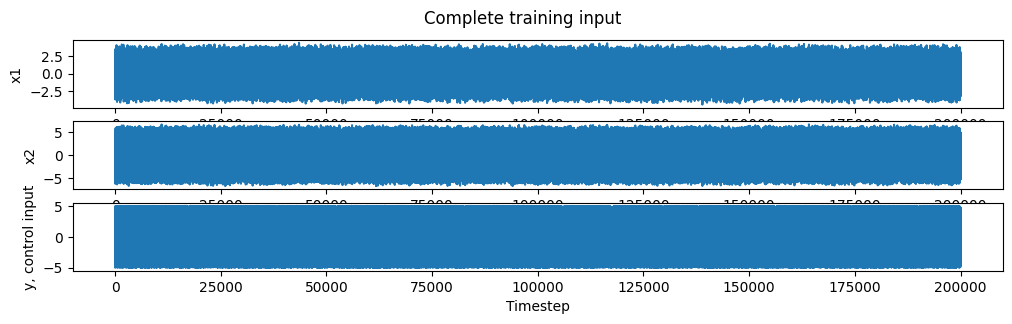

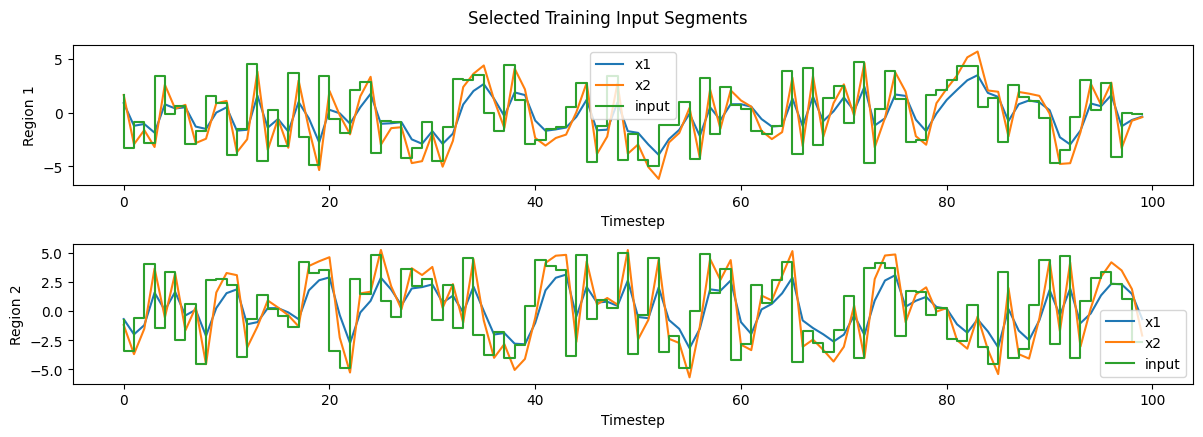

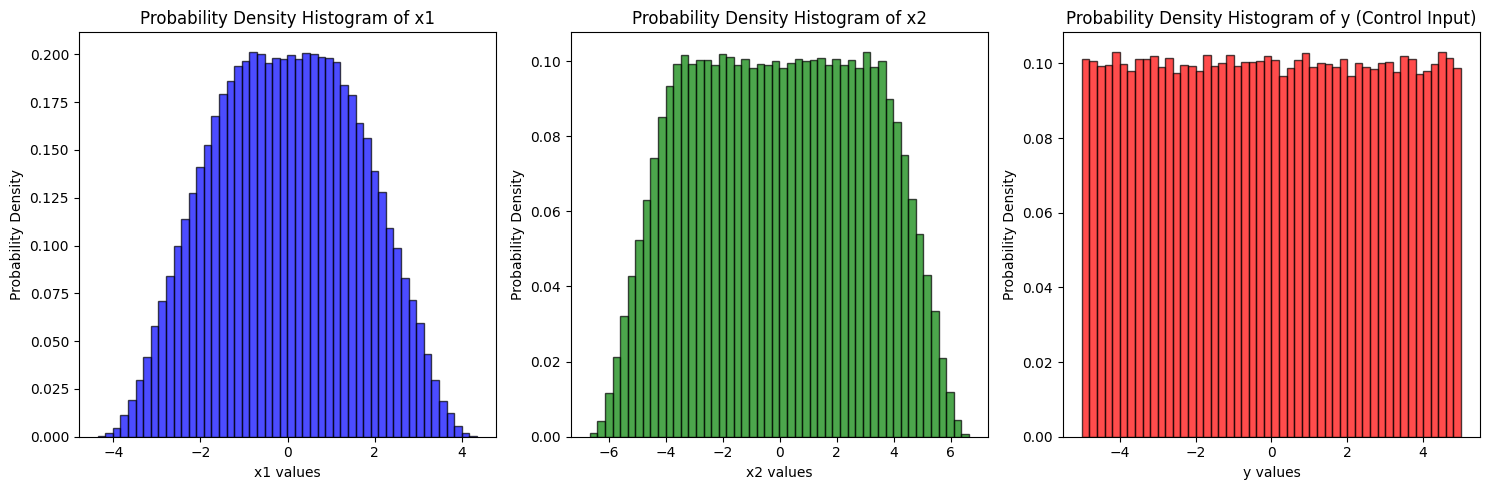

In [36]:
plt.figure(figsize=(12,3))
plt.suptitle("Complete training input")
plt.subplot(3,1,1)

plt.plot(x_output[0,:], label="x1")
plt.xlabel("x1, system response")
plt.ylabel("x1")
plt.subplot(3,1,2)

plt.plot(x_output[1,:],label="x2")
plt.xlabel("x2, system response")
plt.ylabel("x2")
plt.subplot(3,1,3)
plt.plot(u_seq, drawstyle='steps',label="input")
plt.xlabel("Timestep")
plt.ylabel("y, control input")

plt.show()

mm_list = [2000, t_tot - 2000] 
window_size = 100

plt.figure(figsize=(12, 6)) 

for idx, mm in enumerate(mm_list, 1):
    plt.subplot(3, 1, idx)
    plt.plot(x_output[0, mm:mm+window_size], label="x1")
    plt.plot(x_output[1, mm:mm+window_size], label="x2")
    plt.plot(u_seq[mm:mm+window_size], drawstyle='steps', label="input")

    plt.xlabel("Timestep")
    plt.ylabel(f"Region {idx}")  
    plt.legend()

plt.suptitle("Selected Training Input Segments")
plt.tight_layout()  
plt.show()

x1 = x_output[0, :]
x2 = x_output[1, :]
y = u_seq_new.flatten()  

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(x1, bins=50, density=True, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title("Probability Density Histogram of x1")
axes[0].set_xlabel("x1 values")
axes[0].set_ylabel("Probability Density")

axes[1].hist(x2, bins=50, density=True, alpha=0.7, color='green', edgecolor='black')
axes[1].set_title("Probability Density Histogram of x2")
axes[1].set_xlabel("x2 values")
axes[1].set_ylabel("Probability Density")

axes[2].hist(y, bins=50, density=True, alpha=0.7, color='red', edgecolor='black')
axes[2].set_title("Probability Density Histogram of y (Control Input)")
axes[2].set_xlabel("y values")
axes[2].set_ylabel("Probability Density")

plt.tight_layout()
plt.show()

x = x_output
u = u_seq_new.reshape(1,-1)

In [37]:
import pickle

data = {'x': x, 'u': u}
pickle_filename = 'x_and_u_300,000.pickle'
with open(pickle_filename, 'wb') as f:
    pickle.dump(data, f)
print(f"Saved 'x' and 'u' arrays to {pickle_filename}")
pickle_filename = 'x_and_u_300,000.pickle'

with open(pickle_filename, 'rb') as f:
    loaded_data = pickle.load(f)
x = loaded_data['x']
u = loaded_data['u']
print("Loaded 'x' array shape:", x.shape)
print("Loaded 'u' array shape:", u.shape)


Saved 'x' and 'u' arrays to x_and_u_300,000.pickle
Loaded 'x' array shape: (2, 200000)
Loaded 'u' array shape: (1, 200000)


In [38]:
# def f_ss(x0,u):
#     A = np.array([[0.3,0.1], [0.1, 0.2]])
#     B = np.array([[0.5],[1.0]])
#     mu = np.array([[0],[0]])*0
#     w = np.array([[0.05],[0.1]])
#     x = A@x0+B*u + np.random.normal(mu,w,size=(2,1))
#     return x

# def f_ss_multistep(x0,u):
#     step = len(u)
#     output = np.zeros([2,step])
#     for i in range(step):
#         x_next = f_ss(x0,u[i])
#         x0 = np.copy(x_next)
#         output[:,i] = x_next.reshape(-1)
#     return output

# K = np.array([-0.6167,-1.2703])
# x0 = np.array([[0],[0]])
# print(x0.shape)

# u_rand = np.random.uniform(low=-5, high=5, size=(100000))
# #u_rand = np.append(u_rand,(np.random.uniform(low=-1, high=1, size=(200000))))
# #u_rand = np.append(u_rand,(np.random.uniform(low=-5, high=5, size=(20000))))
# u_seq = np.append(np.zeros(2000),u_rand)

# def dynamic_data_generator(x0,u_seq):
#     repeat_LQR = 5
#     step = len(u_seq)
#     output = np.zeros([x0.shape[0],step])
#     count = repeat_LQR
#     out_bound_index = False
#     for i in range(step):
#         u_max = 3 + 2 * np.random.random(1)
#         u_min = -u_max
#         x_next = f_ss(x0,u_seq[i])
#         x0 = np.copy(x_next)
#         if i!=step-1:
#             if (abs(x0[0])>5 or abs(x0[1])>6):
#                 out_bound_index = True
#                 count = repeat_LQR
#                 u_seq[i+1] = min(u_max, max(u_min, K@x0.reshape(-1)))
#             else:
#                 if out_bound_index and count!=0:
#                     u_seq[i+1] = min(u_max, max(u_min, K@x0.reshape(-1)))
#                     count = count-1
#                 elif count==0:
#                     out_bound_index = False
#         output[:,i] = x_next.reshape(-1)
#     return output, u_seq

# x_output, u_seq_new = dynamic_data_generator(x0,u_seq)

# plt.figure(figsize=(10,8))
# plt.suptitle("Complete training input")

# plt.subplot(4,1,1)
# plt.plot(x_output[0,:], label="x1")
# plt.xlabel("x1, system response")
# plt.ylabel("x1")

# plt.subplot(4,1,2)
# plt.plot(x_output[1,:],label="x2")
# plt.xlabel("x2, system response")
# plt.ylabel("x2")

# plt.subplot(4,1,3)
# plt.plot(u_seq, drawstyle='steps',label="input")
# plt.xlabel("Timestep")
# plt.ylabel("u, control input")

# plt.subplot(4,1,4)
# plt.plot(u_seq_new, drawstyle='steps',label="input")
# plt.xlabel("Timestep")
# plt.ylabel("u_adjusted, control input")

# plt.show()

# x = x_output
# u = u_seq_new.reshape(1,-1)

In [39]:
# import pickle

# data = {'x': x, 'u': u}
# pickle_filename = 'x_and_u.pickle'
# with open(pickle_filename, 'wb') as f:
#     pickle.dump(data, f)
# print(f"Saved 'x' and 'u' arrays to {pickle_filename}")
# pickle_filename = 'x_and_u.pickle'

# with open(pickle_filename, 'rb') as f:
#     loaded_data = pickle.load(f)
# x = loaded_data['x']
# u = loaded_data['u']
# print("Loaded 'x' array shape:", x.shape)
# print("Loaded 'u' array shape:", u.shape)


In [40]:
window = 10
P = 10

# Function to normalize an array to the scale of -1 and 1
def normalize_array(arr):
    if arr.shape[0]>1:
        min_val = np.min(arr,axis=1).reshape(-1,1)
        max_val = np.max(arr, axis = 1).reshape(-1,1)
        diff = (max_val - min_val).reshape(-1,1)
        print(diff)
        normalized_arr = -1 + 2 * ((arr - min_val) / diff)
    else:
        min_val = np.min(arr)
        max_val = np.max(arr)
        diff = (max_val - min_val)
        normalized_arr = -1 + 2 * ((arr - min_val) / diff)
    return normalized_arr

x_normalized = normalize_array(x)
u_normalized = normalize_array(u)

Xs = u_normalized.reshape(-1,1)
Ys = x_normalized.transpose()

training_ratio = 0.8 # portion of train set 
cut_index = int(training_ratio*x.shape[1]) # index number to separate the training and validation set

Xs_train = Xs[0:cut_index]
Ys_train = Ys[0:cut_index]
Xs_val = Xs[cut_index:]
Ys_val = Ys[cut_index:]

# save model parameters
model_params = dict()
model_params["x_min"] = np.min(x,axis=1)
model_params["x_max"] = np.max(x,axis=1)
model_params["u_min"] = np.min(u,axis=1)
model_params["u_max"] = np.max(u,axis=1)
model_params["window"] = window
model_params["P"] = P


print(f"Xs (normalized u sequence) shape = {Xs.shape}, Ys (normalized x1-x2 sequence) shape = {Ys.shape}")

[[ 8.700686  ]
 [13.30835345]]
Xs (normalized u sequence) shape = (200000, 1), Ys (normalized x1-x2 sequence) shape = (200000, 2)


In [41]:
X_train = []
X_train_past = []
Y_train = []

for i in range(window, len(Xs_train)-P):
    X_train.append((Xs_train[i-window:i+P,0]))
    Ys_train_add = np.copy(Ys_train[i-window:i,:])
    X_train_past.append(Ys_train_add)
    Y_train.append(Ys_train[i:i+P,:])

X_val = []
X_val_past = []
Y_val = []

for i in range(window, len(Xs_val)-P):
    X_val.append(Xs_val[i-window:i+P,0])
    Ys_val_add = np.copy(Ys_val[i-window:i,:])
    X_val_past.append(Ys_val_add)
    Y_val.append(Ys_val[i:i+P,:])

X_train_array = np.array(X_train)
X_train_array = X_train_array.reshape(X_train_array.shape[0],X_train_array.shape[1],1)
print(X_train_array.shape)
X_train_orig = torch.tensor(X_train_array).type(torch.float32).to(device)                                 # (past + future) covariate, length = window + P
X_train_past_orig = torch.tensor(np.array(X_train_past)).type(torch.float32).to(device)               # past covariate + past series, length = window, dim = input_dim + output_dim
Y_train_orig = torch.tensor(np.array(Y_train)).type(torch.float32).to(device)                        # target: future output, length = P

X_val_array = np.array(X_val)
X_val_array = X_val_array.reshape(X_val_array.shape[0],X_val_array.shape[1],1)
print(X_val_array.shape)
X_val_orig = torch.tensor(X_val_array).type(torch.float32).to(device)                                 # (past + future) covariate, length = window + P
X_val_past_orig = torch.tensor(np.array(X_val_past)).type(torch.float32).to(device)               # past covariate + past series, length = window, dim = input_dim + output_dim
Y_val_orig = torch.tensor(np.array(Y_val)).type(torch.float32).to(device)                        # target: future output, length = P

# Training set
X_past = torch.cat([X_train_past_orig[:,:],X_train_orig[:,:window]],dim=2)
X_future_covariates = X_train_orig[:,-P:,:]

x_in = [X_past, X_future_covariates, None] # Training input
Y_in = Y_train_orig[:,:,:].to(device)   # Training output

# Validation set
X_past_val = torch.cat([X_val_past_orig[:,:],X_val_orig[:,:window,:]],dim=2)
X_future_covariates_val = X_val_orig[:,-P:,:]

x_val = [X_past_val, X_future_covariates_val,None] # Validation input
Y_val = Y_val_orig[:,:,:].to(device)             # Validation output

print(f"x_past shape = {X_past.shape}, x_future_covariate shape = {X_future_covariates.shape}, target shape = {Y_in.shape}")
print(f"x_past_val shape = {X_past_val.shape}, x_future_covariate_val shape = {X_future_covariates_val.shape}, target_val shape = {Y_val.shape}")        # Validation output
    


(159980, 20, 1)
(39980, 20, 1)
x_past shape = torch.Size([159980, 10, 3]), x_future_covariate shape = torch.Size([159980, 10, 1]), target shape = torch.Size([159980, 10, 2])
x_past_val shape = torch.Size([39980, 10, 3]), x_future_covariate_val shape = torch.Size([39980, 10, 1]), target_val shape = torch.Size([39980, 10, 2])


# Build TiDE Model

In [42]:
output_dim = 2
future_cov_dim = 1

nominal_TiDE = TideModule(
        input_dim = output_dim + future_cov_dim,
        output_dim = output_dim,
        future_cov_dim = future_cov_dim,
        static_cov_dim = 0,
        input_chunck_length = window,
        output_chunk_length = P,
        nr_params = 3,
        num_encoder_layers = 1,
        num_decoder_layers = 1,
        decoder_output_dim = 16,
        hidden_size = 128,
        temporal_decoder_hidden = 32,
        temporal_width_past = 4,
        temporal_width_future = 4,
        use_layer_norm = True,
        dropout = 0.2,
    ).to(device)

optimizer = torch.optim.Adam(nominal_TiDE.parameters(),lr=0.001, weight_decay=0.002)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.90)
num_epoch = 1000
model_params["model"] = nominal_TiDE

path = ''
dump(model_params, open(path + 'TiDE_0401_epoch1000_300,000.pkl', 'wb'))

In [43]:
from tqdm.auto import tqdm

train_dataset = TensorDataset(X_past, X_future_covariates, Y_in)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

best_model = None
best_val_loss = float("inf")

save_train_loss = np.zeros(num_epoch)
save_val_loss = np.zeros(num_epoch)

counter = 0
patience = 50

epoch = 0
loss = 0
val_loss = 0

pbar = tqdm(range(num_epoch))  # 🔥 여기

for epoch in pbar:
    for x_past, x_future, y_in in train_loader:
        x_in = [x_past, x_future, None]

        nominal_TiDE.train()
        optimizer.zero_grad()
        output = nominal_TiDE(x_in)
        quantiles = [0.05,0.50,0.95]
        loss = quantile_loss(output,y_in,quantiles)
        loss.backward()
        optimizer.step()

    nominal_TiDE.eval()
    val_out = nominal_TiDE(x_val)
    val_loss = quantile_loss(val_out,Y_val,quantiles)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = nominal_TiDE.state_dict()
        counter = 0   
        
    save_train_loss[epoch] = loss
    save_val_loss[epoch] = val_loss

    scheduler.step()

    # 🔥 이거 추가
    pbar.set_description(
        f"Epoch = {epoch}, Train loss = {loss:.4f}, Val loss = {val_loss:.4f}"
    )

torch.save(nominal_TiDE.state_dict(), 'TiDE_0401_epoch1000.pth')

  0%|          | 0/1000 [00:00<?, ?it/s]

In [44]:
# import os
# current_directory = os.getcwd()
# file_name = 'nominal_params_w10_mid_noise_stable.pth'
# save_path = os.path.join(current_directory, file_name)
# torch.save(best_model, save_path)


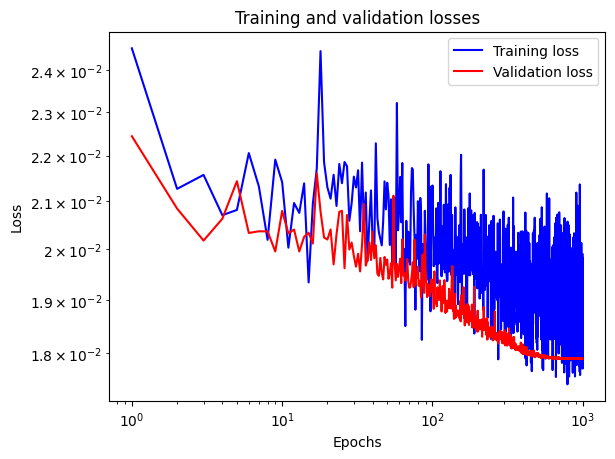

In [45]:
loss = save_train_loss
val_loss = save_val_loss
epochs=range(1,len(loss)+1)
plt.figure()
plt.semilogy(epochs, loss,'b', label='Training loss')
plt.semilogy(epochs, val_loss,'r', label='Validation loss')
plt.title('Training and validation losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xscale('log')
#plt.yscale('log')
plt.legend()
#plt.savefig('lossLSTM32.png')
plt.show()

In [46]:
combined = np.vstack((save_val_loss, save_train_loss))
pd.DataFrame(combined).to_csv('loss_history.csv', index=False, header=False)

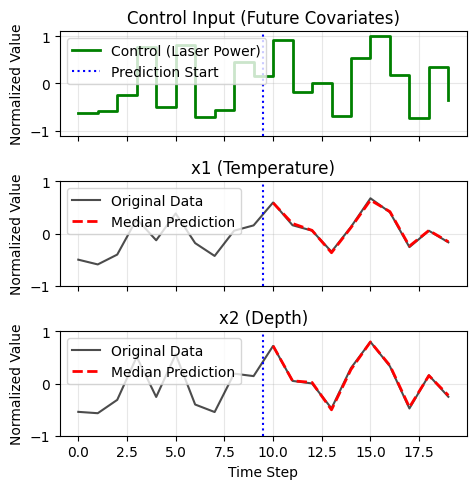

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import torch

item = 382
lookback_len = 10  # 시각화할 과거 스텝 길이
control_idx = -1   # X_future_covariates에서 제어 성분의 인덱스 (확인 필요)

# 1. 데이터 준비 및 추론
x_plot_past = X_past_val[item,:,:].unsqueeze(0)
x_plot_future = X_future_covariates_val[item,:,:].unsqueeze(0)
y_plot_val = Y_val[item,:,:].unsqueeze(0)

nominal_TiDE.eval()
with torch.no_grad():
    y_hat = nominal_TiDE([x_plot_past, x_plot_future, None])

# 2. 넘파이 변환 및 슬라이싱
past_np = x_plot_past.cpu().squeeze(0).numpy()         # [window, dim]
future_actual_np = y_plot_val.cpu().squeeze(0).numpy()    # [P, dim]
future_pred_np = y_hat[0].detach().cpu().numpy()       # [P, dim, quantiles]
future_cov_np = x_plot_future.cpu().squeeze(0).numpy()    # [P, dim]

# 3. 시간축 설정
P = y_plot_val.shape[1]
total_steps = lookback_len + P
time_full = np.arange(total_steps)
time_future = np.arange(lookback_len, total_steps)

# 4. 시각화 (3행 1열) - 순서 조정
fig, axes = plt.subplots(3, 1, figsize=(5, 5), sharex=True)

# --- Plot 1 (Top): Control Input (Laser Power) ---
# 과거 제어 이력(10개) + 미래 제어 시나리오(P개) 연결
total_control = np.concatenate([past_np[-lookback_len:, control_idx], future_cov_np[:, control_idx]])

axes[0].step(time_full, total_control, where='post', label="Control (Laser Power)", color='green', linewidth=2)
axes[0].axvline(x=lookback_len - 0.5, color='blue', linestyle=':', label='Prediction Start')
axes[0].set_title('Control Input (Future Covariates)')
axes[0].set_ylabel('Normalized Value')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-1.1, 1.1)

# --- Plot 2 & 3: Temperature (x1) and Depth (x2) ---
titles = ['x1 (Temperature)', 'x2 (Depth)']
for i, ax_idx in enumerate([1, 2]):  # axes[1]과 axes[2]에 그리기
    # 과거 실제값(10개) + 미래 실제값(P개) 연결
    total_original = np.concatenate([past_np[-lookback_len:, i], future_actual_np[:, i]])
    
    axes[ax_idx].plot(time_full, total_original, label="Original Data", color='black', alpha=0.7, linewidth=1.5)
    axes[ax_idx].plot(time_future, future_pred_np[:, i, 1], label="Median Prediction", 
                     color='red', linestyle='--', linewidth=2)
    
    axes[ax_idx].set_title(titles[i])
    axes[ax_idx].set_ylabel('Normalized Value')
    axes[ax_idx].axvline(x=lookback_len - 0.5, color='blue', linestyle=':')
    axes[ax_idx].legend(loc='upper left')
    axes[ax_idx].grid(True, alpha=0.3)
    axes[ax_idx].set_ylim(-1, 1)

# 공통 x축 라벨
axes[2].set_xlabel('Time Step')

plt.tight_layout()
plt.show()

forward time = 0.002717256546020508


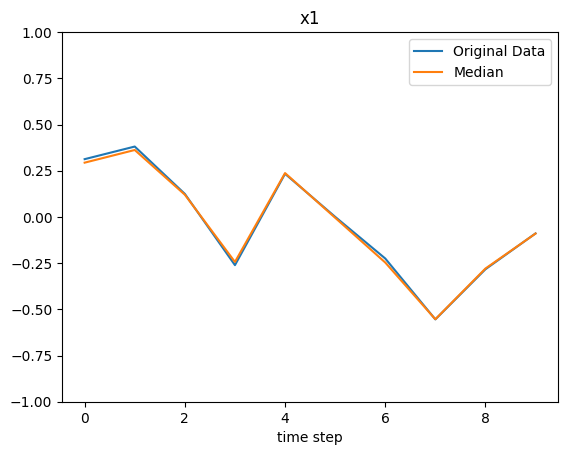

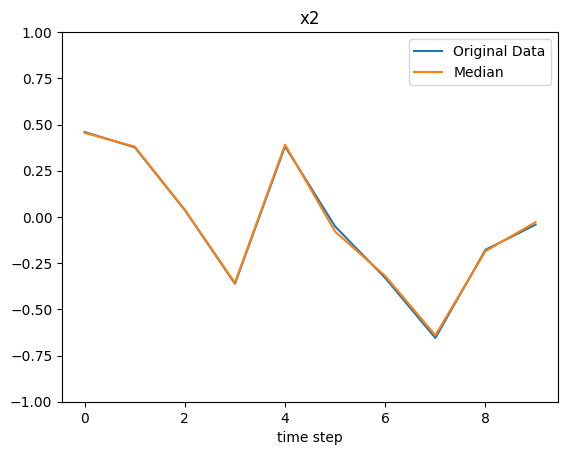

In [48]:
item = 100 # Select the index for visualizing the results using validation data
item = 1250

x_plot_past = X_past_val[item,:,:].unsqueeze(0)
x_plot_future = X_future_covariates_val[item,:,:].unsqueeze(0)
x_plot_val = [x_plot_past, x_plot_future, None]
y_plot_val = Y_val[item,:,:].unsqueeze(0)

nominal_TiDE.eval()

time1 = time.time()
y_hat = nominal_TiDE(x_plot_val)
time2 = time.time()
print(f"forward time = {time2-time1}")

# plot x1
plt.figure()
plt.plot(y_plot_val.to("cpu")[:,:,0].squeeze().numpy(),label="Original Data")
plt.plot(y_hat[:,:,0,1].squeeze().detach().to("cpu").numpy(),label="Median")
#plt.plot(y_hat[:,:,0,0].squeeze().detach().to("cpu").numpy(),label="Lower quantile")
#plt.plot(y_hat[:,:,0,2].squeeze().detach().to("cpu").numpy(),label="Upper quantile")
plt.title('x1')
plt.xlabel('time step')
plt.ylim(-1,1)
# plt.ylim([-10,5])

#plt.fill_between(range(P),
#                 y1=y_hat[:,:,0,0].squeeze().detach().to("cpu").numpy(),
#                 y2=y_hat[:,:,0,2].squeeze().detach().to("cpu").numpy(),
#                 alpha=0.2, color='gray')
plt.legend()

# plot x2
plt.figure()
plt.plot(y_plot_val.to("cpu")[:,:,1].squeeze().numpy(),label="Original Data")
plt.plot(y_hat[:,:,1,1].squeeze().detach().to("cpu").numpy(),label="Median")
#plt.plot(y_hat[:,:,1,0].squeeze().detach().to("cpu").numpy(),label="Lower quantile")
#plt.plot(y_hat[:,:,1,2].squeeze().detach().to("cpu").numpy(),label="Upper quantile")
plt.title('x2')
plt.xlabel('time step')
# plt.ylim([-5,2])

#plt.fill_between(range(P),
#                 y1=y_hat[:,:,1,0].squeeze().detach().to("cpu").numpy(),
#                 y2=y_hat[:,:,1,2].squeeze().detach().to("cpu").numpy(),
#                 alpha=0.2, color='gray')
plt.legend()
plt.ylim(-1,1)
plt.show()

In [49]:
true_x1 = y_plot_val.to("cpu")[:,:,0].squeeze().numpy()
median_x1 = y_hat[:,:,0,1].squeeze().detach().to("cpu").numpy()
lb_x1 = y_hat[:,:,0,0].squeeze().detach().to("cpu").numpy()
ub_x1 = y_hat[:,:,0,2].squeeze().detach().to("cpu").numpy()

true_x2 = y_plot_val.to("cpu")[:,:,1].squeeze().numpy()
median_x2 = y_hat[:,:,1,1].squeeze().detach().to("cpu").numpy()
lb_x2 = y_hat[:,:,1,0].squeeze().detach().to("cpu").numpy()
ub_x2 = y_hat[:,:,1,2].squeeze().detach().to("cpu").numpy()

save_predict_response = np.vstack([true_x1,median_x1,lb_x1,ub_x1,true_x2,median_x2,lb_x2,ub_x2])
# Save to a single CSV file
pd.DataFrame(save_predict_response).to_csv('save_response_evaluation.csv', index=False, header=False)

### Evaluation

In [50]:
def sMAPE(y_true,y_hat):
    MAPE_ind = 100* np.mean(np.abs((y_true - y_hat) / (np.abs(y_true)+np.abs(y_hat))))
    return MAPE_ind

def SSE_compute(y_true, y_hat):
    return np.sum((y_true - y_hat)**2)

# Main code for eval
MAPE_x1 = []
MAPE_x2 = []
SSE_x1 = 0
SSE_x2 = 0


for item in range(X_past_val.shape[0]):
    x_past = X_past_val[item,:,:].unsqueeze(0)
    x_future = X_future_covariates_val[item,:,:].unsqueeze(0)
    x_val = [x_past, x_future, None]
    y_val = Y_val[item,:,:].unsqueeze(0)
    y_hat = nominal_TiDE(x_val)
    # sMAPE
    MAPE_x1.append(sMAPE(y_val.to("cpu")[:,:,0].squeeze().numpy(), y_hat[:,:,0,1].squeeze().detach().to("cpu").numpy()))
    MAPE_x2.append(sMAPE(y_val.to("cpu")[:,:,1].squeeze().numpy(), y_hat[:,:,1,1].squeeze().detach().to("cpu").numpy()))
    # RMSE
    SSE_x1 = SSE_x1 + SSE_compute(y_val.to("cpu")[:,:,0].squeeze().numpy(), y_hat[:,:,0,1].squeeze().detach().to("cpu").numpy())
    SSE_x2 = SSE_x2 + SSE_compute(y_val.to("cpu")[:,:,1].squeeze().numpy(), y_hat[:,:,1,1].squeeze().detach().to("cpu").numpy())


n_item = Y_val.shape[0] * Y_val.shape[1]
RRMSE_x1 = np.sqrt(np.sum(SSE_x1)/n_item/np.var(Ys_val[:,0]))*100
RRMSE_x2 = np.sqrt(np.sum(SSE_x2)/n_item/np.var(Ys_val[:,1]))*100


MAPE_x1 = np.mean(MAPE_x1)
MAPE_x2 = np.mean(MAPE_x2)

print(f"MAPE_x1 = {MAPE_x1:.2f}%, MAPE_x2 = {MAPE_x2:.2f}%")   
print(f"RRMSE_x1 = {RRMSE_x1:.2f}, RRMSE_x2 = {RRMSE_x2:.2f}")  

MAPE_x1 = 4.89%, MAPE_x2 = 4.75%
RRMSE_x1 = 3.78, RRMSE_x2 = 3.79
